# Exercise 3.1 - Solving CartPole and LunarLander with A2C

This notebook addresses the requested A2C exercise. The workflow is:

1. validate the implementation on `CartPole-v1`;
2. use the same A2C utilities on `LunarLander-v3`;
3. report the useful evidence from the old exploratory notebook `Lab3_A2C.ipynb`;
4. compare the best LunarLander checkpoints and the stochastic policy temperature;
5. include local render cells for a small number of visual episodes.

All reusable code is imported from `src/dla_lab3/a2c.py`. The notebook is therefore a report and experiment driver, not a place where the algorithm is reimplemented cell by cell.

## Methodological Notes

The previous version of this notebook contained a long `REINFORCE` run on LunarLander with `8000` episodes. That cell was removed because it did not match the exercise request: the requested algorithm is **Advantage Actor-Critic (A2C)**.

A2C is still an on-policy policy-gradient method, but it replaces Monte Carlo returns alone with a learned critic. The actor updates the policy using an advantage estimate, while the critic learns the state-value function. In this notebook we use Generalized Advantage Estimation (GAE):

$$
A_t = \delta_t + \gamma \lambda \delta_{t+1} + \gamma^2 \lambda^2 \delta_{t+2} + \dots
$$

with

$$
\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t).
$$

The final LunarLander section uses the old checkpoints saved during the exploratory work because they document the path to the best result without forcing a slow retraining during every notebook run.

## Checkpoints and Reproducibility

The old LunarLander checkpoints are not theoretical standard values. They are saved experimental artifacts from the old exploratory notebook. In this final notebook they serve two purposes:

- they make it possible to reproduce the final evaluation without retraining for a long time;
- they document which training choices were tried before selecting the final policy.

The runnable training cell below exposes the same main variants used in the old notebook. Short presets are provided for quick checks; full presets reproduce the old settings but can take a long time.

In [1]:
from pathlib import Path
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from dla_lab3 import (
    A2CConfig,
    a2c_from_env,
    evaluate_a2c_policy,
    load_a2c_checkpoint,
    lunar_a2c_from_env,
    make_env,
    observation_scale,
    run_a2c_episode,
    set_seed,
    train_a2c_single_env,
    train_a2c_vectorized,
)
from dla_lab3.paths import checkpoint_dir, artifact_dir

SEED = 2112
set_seed(SEED)

print(f"Project root: {PROJECT_ROOT}")
print(f"Checkpoint folder: {checkpoint_dir()}")

Project root: /mnt/c/Users/checc/OneDrive/Desktop/DLA/DLA_Lab/Reinforcment LLM/LAB_3_LLM
Checkpoint folder: /mnt/c/Users/checc/OneDrive/Desktop/DLA/DLA_Lab/Reinforcment LLM/LAB_3_LLM/checkpoints


In [ ]:
from matplotlib import animation
from IPython.display import HTML, display


def show_frames(frames, interval=30, max_display_frames=300):
    # Args:
    #     frames: RGB arrays returned by Gymnasium `render_mode="rgb_array"`.
    #     interval: Delay between displayed frames in milliseconds.
    #     max_display_frames: Maximum number of frames kept in the notebook output.
    # What it does:
    #     Downsamples long episodes if needed and renders the episode inside
    #     Jupyter, which is more reliable than a separate Pygame window in WSL.
    # Output:
    #     HTML animation displayed in the current notebook cell.

    if not frames:
        print("No frames collected.")
        return

    if len(frames) > max_display_frames:
        step = int(np.ceil(len(frames) / max_display_frames))
        frames = frames[::step]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.axis("off")
    image = ax.imshow(frames[0])

    def update(frame):
        image.set_data(frame)
        return (image,)

    anim = animation.FuncAnimation(fig, update, frames=frames, interval=interval, blit=True)
    plt.close(fig)
    display(HTML(anim.to_jshtml()))

## 1. Environment Check

CartPole is used as a quick validation environment. LunarLander is harder because the policy must control four discrete actions, stabilize velocity and angle, and land between the flags.

In [2]:
for env_id, kwargs in [
    ("CartPole-v1", {}),
    ("LunarLander-v3", {"continuous": False, "enable_wind": False}),
]:
    env = make_env(env_id, seed=SEED, **kwargs)
    obs, _ = env.reset(seed=SEED)
    action = env.action_space.sample()
    next_obs, reward, terminated, truncated, _ = env.step(action)

    print("\n" + "=" * 72)
    print(env_id)
    print("Observation space:", env.observation_space)
    print("Action space:", env.action_space)
    print("Initial observation:", np.round(obs, 4))
    print("Sample action:", action)
    print("Next observation:", np.round(next_obs, 4))
    print("Reward:", round(float(reward), 4))
    print("Terminated:", terminated, "| Truncated:", truncated)

    env.close()


CartPole-v1
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Initial observation: [-0.0416  0.0333 -0.0422  0.0172]
Sample action: 0
Next observation: [-0.0409 -0.1612 -0.0418  0.2963]
Reward: 1.0
Terminated: False | Truncated: False

LunarLander-v3
Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space: Discrete(4)
Initial observation: [-0.0032  1.4177 -0.3276  0.3024  0.0038  0.0742  0.      0.    ]
Sample action: 1
Next observation: [-0.0065  1.4239 -0.3346  0.2761  0.0089  0.1034  0.      0.    ]
Reward: 0.0256
Terminated: False | Truncated: False


## 2. CartPole Validation with A2C

This cell trains A2C on CartPole. The setup is intentionally moderate: it is long enough to validate the algorithm, but not comparable to the expensive LunarLander runs.

The old exploratory notebook solved CartPole with A2C and GAE at about episode 425. A final greedy evaluation over 100 episodes gave average return `500.0`, standard deviation `0.0` and average length `500.0`. Those numbers are useful as a target when rerunning this clean notebook.

In [3]:
set_seed(SEED)

train_env = make_env("CartPole-v1", seed=SEED)
eval_env = make_env("CartPole-v1", seed=SEED + 1000)
obs_scale_cp = observation_scale("CartPole-v1")

net_cp = a2c_from_env(train_env, hidden_size=128)

config_cp = A2CConfig(
    gamma=0.99,
    lr=3e-4,
    value_coef=0.5,
    entropy_coef=0.01,
    entropy_coef_min=0.001,
    num_episodes=800,
    max_episode_steps=500,
    eval_every=25,
    eval_episodes=20,
    gae_lambda=0.95,
    normalize_advantage=True,
    grad_clip=0.5,
    solved_threshold=475.0,
    checkpoint_path=str(checkpoint_dir("a2c_cartpole_gae.pt")),
    stop_when_solved=True,
)

history_cp = train_a2c_single_env(net_cp, train_env, eval_env, obs_scale_cp, config_cp)

train_env.close()
eval_env.close()

print("Solved:", history_cp["solved"])
print("Best evaluation return:", round(history_cp["best_eval_return"], 2))
print("Checkpoint:", history_cp["checkpoint_path"])

Solved: True
Best evaluation return: 491.7
Checkpoint: /mnt/c/Users/checc/OneDrive/Desktop/DLA/DLA_Lab/Reinforcment LLM/LAB_3_LLM/checkpoints/a2c_cartpole_gae.pt


In [4]:
eval_env = make_env("CartPole-v1", seed=SEED + 2000)
net_cp_eval = a2c_from_env(eval_env, hidden_size=128)

cartpole_ckpt = checkpoint_dir("a2c_cartpole_gae.pt", create=False)
if cartpole_ckpt.exists():
    load_a2c_checkpoint(net_cp_eval, cartpole_ckpt)
else:
    net_cp_eval.load_state_dict(net_cp.state_dict())
    net_cp_eval.eval()

cartpole_metrics = evaluate_a2c_policy(
    eval_env,
    net_cp_eval,
    obs_scale_cp,
    n_eval=100,
    mode="greedy",
    seed_start=40_000,
    max_episode_steps=500,
)
eval_env.close()

print("CARTPOLE GREEDY EVALUATION")
print("Average return:      ", round(cartpole_metrics["avg_return"], 2))
print("Std return:          ", round(cartpole_metrics["std_return"], 2))
print("Min return:          ", round(cartpole_metrics["min_return"], 2))
print("Max return:          ", round(cartpole_metrics["max_return"], 2))
print("Average length:      ", round(cartpole_metrics["avg_length"], 2))
print("Terminated episodes: ", f"{cartpole_metrics['terminated']}/100")
print("Truncated episodes:  ", f"{cartpole_metrics['truncated']}/100")

CARTPOLE GREEDY EVALUATION
Average return:       494.51
Std return:           19.68
Min return:           389.0
Max return:           500.0
Average length:       494.51
Terminated episodes:  10/100
Truncated episodes:   90/100


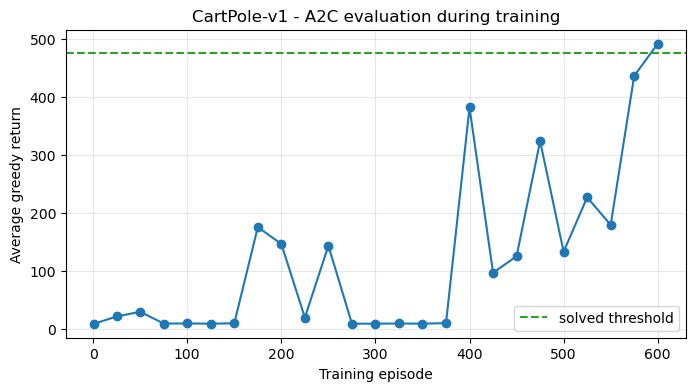

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(history_cp["eval_episodes"], history_cp["eval_avg_returns"], marker="o")
plt.axhline(config_cp.solved_threshold, linestyle="--", color="tab:green", label="solved threshold")
plt.xlabel("Training episode")
plt.ylabel("Average greedy return")
plt.title("CartPole-v1 - A2C evaluation during training")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [6]:
# Visual check: run only in the local Linux/VS Code setup with display support.
# This cell opens the Gymnasium render window and executes two greedy episodes.

RUN_CARTPOLE_RENDER = True

if RUN_CARTPOLE_RENDER:
    render_env = make_env("CartPole-v1", seed=SEED + 3000, render_mode="human")
    render_net = a2c_from_env(render_env, hidden_size=128)
    load_a2c_checkpoint(render_net, cartpole_ckpt)

    for idx, episode_seed in enumerate([SEED + 3100, SEED + 3101], start=1):
        episode = run_a2c_episode(
            render_env,
            render_net,
            obs_scale_cp,
            mode="greedy",
            max_episode_steps=500,
            seed=episode_seed,
        )
        print(f"CartPole render episode {idx}: return={episode['return']:.1f}, length={episode['length']}")

    render_env.close()
else:
    print("CartPole render skipped. Set RUN_CARTPOLE_RENDER = True when running locally with display support.")

CartPole render episode 1: return=500.0, length=500
CartPole render episode 2: return=500.0, length=500


In [ ]:
# Inline visual check for CartPole.
# This avoids the fragile external Pygame window and displays the episode inside Jupyter.

SHOW_CARTPOLE_INLINE_VIDEO = True

if SHOW_CARTPOLE_INLINE_VIDEO:
    video_env = make_env("CartPole-v1", seed=SEED + 3000, render_mode="rgb_array")
    video_net = a2c_from_env(video_env, hidden_size=128)

    if cartpole_ckpt.exists():
        load_a2c_checkpoint(video_net, cartpole_ckpt)
    else:
        video_net.load_state_dict(net_cp.state_dict())
        video_net.eval()

    frames = []
    obs, _ = video_env.reset(seed=SEED + 3100)
    total_reward = 0.0

    with torch.no_grad():
        for _ in range(500):
            frames.append(video_env.render())
            obs_t = torch.tensor(obs, dtype=torch.float32) / obs_scale_cp
            logits, _ = video_net.get_logits_and_value(obs_t)
            action = int(torch.argmax(logits).item())
            obs, reward, terminated, truncated, _ = video_env.step(action)
            total_reward += float(reward)
            if terminated or truncated:
                frames.append(video_env.render())
                break

    video_env.close()
    print(f"CartPole inline episode return={total_reward:.1f}, frames={len(frames)}")
    show_frames(frames, interval=30, max_display_frames=250)
else:
    print("Inline CartPole video skipped.")

## 3. LunarLander A2C: Experimental Path

The old `Lab3_A2C.ipynb` is useful because it shows the actual path taken before selecting the final policy. I keep only the relevant evidence here:

| Attempt | Main idea | Outcome |
|---|---|---|
| Initial vectorized A2C | Direct vectorized training with early architecture | Greedy average return around `-140.48`, success rate `0.0%`; policy mostly selected "do nothing". |
| Stabilized vectorized A2C | Reward scaling, GAE, entropy decay, gradient clipping | Still unstable in the early run; one evaluation had average return around `-575.36`. |
| Separate actor and critic | Separate networks to reduce interference between policy and value learning | Clear improvement; positive returns but not solved by the strict `>= 200` average threshold. |
| Landing refinement | Continue training from the better policy and compare multiple checkpoints | Best practical result among the tried runs. |

This explains why the final notebook does not launch an expensive LunarLander training by default. The training function is available below, but evaluation uses the saved checkpoints from `/home/francescofaggioli/DRL_lab` through `checkpoints/old`.

In [ ]:
# Runnable LunarLander training presets.
# Full presets reproduce the old notebook settings and can take a long time.
# Short presets use the same structure with a smaller timestep budget.

import gymnasium as gym


def make_lunar_env(seed_value):
    def _factory():
        return make_env(
            "LunarLander-v3",
            seed=seed_value,
            continuous=False,
            enable_wind=False,
        )
    return _factory


LUNAR_TRAINING_PRESETS = {
    "separate_short": {
        "description": "Quick check of the separate actor-critic setup.",
        "n_envs": 8,
        "seed_offset": 5000,
        "checkpoint": "a2c_lunarlander_separate_short.pt",
        "initial_checkpoint": None,
        "total_timesteps": 100_000,
        "n_steps": 5,
        "gamma": 0.995,
        "lr": 8.3e-4,
        "value_coef": 0.5,
        "entropy_coef": 0.0005,
        "entropy_coef_min": 0.00001,
        "reward_scale": 1.0,
        "gae_lambda": 1.0,
        "normalize_advantage": False,
        "optimizer_name": "rmsprop",
        "eval_every": 250,
        "eval_episodes": 20,
    },
    "separate_full_old": {
        "description": "Old separate actor-critic run from Lab3_A2C.",
        "n_envs": 16,
        "seed_offset": 5000,
        "checkpoint": "best_a2c_lunarlander_separate_seed2112.pt",
        "initial_checkpoint": None,
        "total_timesteps": 1_000_000,
        "n_steps": 5,
        "gamma": 0.995,
        "lr": 8.3e-4,
        "value_coef": 0.5,
        "entropy_coef": 0.0005,
        "entropy_coef_min": 0.00001,
        "reward_scale": 1.0,
        "gae_lambda": 1.0,
        "normalize_advantage": False,
        "optimizer_name": "rmsprop",
        "eval_every": 250,
        "eval_episodes": 50,
    },
    "landing_refine_short": {
        "description": "Quick refinement from the separate checkpoint.",
        "n_envs": 8,
        "seed_offset": 7000,
        "checkpoint": "a2c_lunarlander_landing_refine_short.pt",
        "initial_checkpoint": "best_a2c_lunarlander_separate_seed2112.pt",
        "total_timesteps": 50_000,
        "n_steps": 5,
        "gamma": 0.995,
        "lr": 1.0e-4,
        "value_coef": 0.5,
        "entropy_coef": 0.00008,
        "entropy_coef_min": 0.00001,
        "reward_scale": 1.0,
        "gae_lambda": 1.0,
        "normalize_advantage": False,
        "optimizer_name": "rmsprop",
        "eval_every": 250,
        "eval_episodes": 20,
    },
    "landing_refine_full_old": {
        "description": "Old landing-refinement run from Lab3_A2C.",
        "n_envs": 16,
        "seed_offset": 7000,
        "checkpoint": "best_a2c_lunarlander_landing_refine_seed2112.pt",
        "initial_checkpoint": "best_a2c_lunarlander_separate_seed2112.pt",
        "total_timesteps": 300_000,
        "n_steps": 5,
        "gamma": 0.995,
        "lr": 1.0e-4,
        "value_coef": 0.5,
        "entropy_coef": 0.00008,
        "entropy_coef_min": 0.00001,
        "reward_scale": 1.0,
        "gae_lambda": 1.0,
        "normalize_advantage": False,
        "optimizer_name": "rmsprop",
        "eval_every": 250,
        "eval_episodes": 100,
    },
}

RUN_LUNAR_TRAINING = False
SELECTED_LUNAR_PRESET = "separate_short"

if RUN_LUNAR_TRAINING:
    preset = LUNAR_TRAINING_PRESETS[SELECTED_LUNAR_PRESET]
    print("Running preset:", SELECTED_LUNAR_PRESET)
    print(preset["description"])

    set_seed(SEED)
    vec_env = gym.vector.SyncVectorEnv(
        [make_lunar_env(SEED + preset["seed_offset"] + i) for i in range(preset["n_envs"])]
    )
    eval_env_ll = make_env(
        "LunarLander-v3",
        seed=SEED + preset["seed_offset"] + 1000,
        continuous=False,
        enable_wind=False,
    )

    obs_scale_ll_raw = torch.ones(8, dtype=torch.float32)
    net_ll_train = lunar_a2c_from_env(eval_env_ll, hidden_size=64)

    if preset["initial_checkpoint"] is not None:
        initial_path = checkpoint_dir("old", preset["initial_checkpoint"], create=False)
        if not initial_path.exists():
            initial_path = checkpoint_dir(preset["initial_checkpoint"], create=False)
        if initial_path.exists():
            load_a2c_checkpoint(net_ll_train, initial_path)
            print("Loaded initial checkpoint:", initial_path)
        else:
            print("Initial checkpoint not found; training starts from random weights:", preset["initial_checkpoint"])

    history_ll = train_a2c_vectorized(
        net_ll_train,
        vec_env,
        eval_env_ll,
        obs_scale_ll_raw,
        total_timesteps=preset["total_timesteps"],
        n_steps=preset["n_steps"],
        gamma=preset["gamma"],
        lr=preset["lr"],
        value_coef=preset["value_coef"],
        entropy_coef=preset["entropy_coef"],
        entropy_coef_min=preset["entropy_coef_min"],
        gae_lambda=preset["gae_lambda"],
        reward_scale=preset["reward_scale"],
        normalize_advantage=preset["normalize_advantage"],
        grad_clip=0.5,
        eval_every=preset["eval_every"],
        eval_episodes=preset["eval_episodes"],
        solved_threshold=200.0,
        checkpoint_path=str(checkpoint_dir(preset["checkpoint"])),
        optimizer_name=preset["optimizer_name"],
        stop_when_solved=False,
    )

    vec_env.close()
    eval_env_ll.close()

    print("Best LunarLander evaluation return:", round(history_ll["best_eval_return"], 2))
    print("Checkpoint:", history_ll["checkpoint_path"])
else:
    print("LunarLander training skipped.")
    print("Available presets:", list(LUNAR_TRAINING_PRESETS))
    print("Set RUN_LUNAR_TRAINING = True and choose SELECTED_LUNAR_PRESET to rerun one variant.")

## 4. Final Checkpoint Comparison

The following table summarizes the final checkpoint comparison from the old run. Each evaluation used 200 episodes.

| Checkpoint | Greedy avg return | Greedy success >= 200 | Stochastic avg return | Stochastic success >= 200 |
|---|---:|---:|---:|---:|
| `best_a2c_lunarlander_separate_seed2112.pt` | `99.97` | `13.5%` | `100.57` | `24.0%` |
| `best_a2c_lunarlander_landing_refine_seed2112.pt` | `125.84` | `12.0%` | `127.61` | `27.5%` |
| `best_a2c_lunarlander_landing_refine_seed2112_best_train.pt` | `126.88` | `13.0%` | `132.43` | `31.0%` |
| `best_a2c_lunarlander_landing_refine_seed2112_last.pt` | `121.46` | `10.5%` | `140.16` | `29.5%` |

The best average stochastic return among these checkpoint-level evaluations is the `last` checkpoint. The `best_train` checkpoint is kept as the selected model for the next analysis because it was the strongest training checkpoint and is the one used in the temperature sweep below.

In [9]:
checkpoint_results = [
    {
        "checkpoint": "best_a2c_lunarlander_separate_seed2112.pt",
        "greedy_avg": 99.97,
        "greedy_success": 13.5,
        "stochastic_avg": 100.57,
        "stochastic_success": 24.0,
    },
    {
        "checkpoint": "best_a2c_lunarlander_landing_refine_seed2112.pt",
        "greedy_avg": 125.84,
        "greedy_success": 12.0,
        "stochastic_avg": 127.61,
        "stochastic_success": 27.5,
    },
    {
        "checkpoint": "best_a2c_lunarlander_landing_refine_seed2112_best_train.pt",
        "greedy_avg": 126.88,
        "greedy_success": 13.0,
        "stochastic_avg": 132.43,
        "stochastic_success": 31.0,
    },
    {
        "checkpoint": "best_a2c_lunarlander_landing_refine_seed2112_last.pt",
        "greedy_avg": 121.46,
        "greedy_success": 10.5,
        "stochastic_avg": 140.16,
        "stochastic_success": 29.5,
    },
]

for row in checkpoint_results:
    print(
        f"{row['checkpoint']}: "
        f"greedy={row['greedy_avg']:.2f} ({row['greedy_success']:.1f}% success), "
        f"stochastic={row['stochastic_avg']:.2f} ({row['stochastic_success']:.1f}% success)"
    )

best_a2c_lunarlander_separate_seed2112.pt: greedy=99.97 (13.5% success), stochastic=100.57 (24.0% success)
best_a2c_lunarlander_landing_refine_seed2112.pt: greedy=125.84 (12.0% success), stochastic=127.61 (27.5% success)
best_a2c_lunarlander_landing_refine_seed2112_best_train.pt: greedy=126.88 (13.0% success), stochastic=132.43 (31.0% success)
best_a2c_lunarlander_landing_refine_seed2112_last.pt: greedy=121.46 (10.5% success), stochastic=140.16 (29.5% success)


## 5. Temperature Sweep

The final old run also evaluated stochastic action selection with different temperatures. A lower temperature makes the policy more deterministic; a higher temperature increases exploration during evaluation.

In [10]:
temperature_results = [
    {"temperature": 0.25, "avg_return": 111.45, "std_return": 106.66, "success_rate": 15.5},
    {"temperature": 0.50, "avg_return": 124.24, "std_return": 99.97, "success_rate": 21.5},
    {"temperature": 0.75, "avg_return": 129.27, "std_return": 102.50, "success_rate": 27.5},
    {"temperature": 1.00, "avg_return": 141.03, "std_return": 101.20, "success_rate": 34.5},
    {"temperature": 1.25, "avg_return": 139.99, "std_return": 102.77, "success_rate": 39.5},
]

best_by_return = max(temperature_results, key=lambda row: row["avg_return"])
best_by_success = max(temperature_results, key=lambda row: row["success_rate"])

for row in temperature_results:
    print(
        f"T={row['temperature']:.2f} | "
        f"avg return={row['avg_return']:.2f} | "
        f"std={row['std_return']:.2f} | "
        f"success={row['success_rate']:.1f}%"
    )

print("\nBest average return:", best_by_return)
print("Best success rate:", best_by_success)

T=0.25 | avg return=111.45 | std=106.66 | success=15.5%
T=0.50 | avg return=124.24 | std=99.97 | success=21.5%
T=0.75 | avg return=129.27 | std=102.50 | success=27.5%
T=1.00 | avg return=141.03 | std=101.20 | success=34.5%
T=1.25 | avg return=139.99 | std=102.77 | success=39.5%

Best average return: {'temperature': 1.0, 'avg_return': 141.03, 'std_return': 101.2, 'success_rate': 34.5}
Best success rate: {'temperature': 1.25, 'avg_return': 139.99, 'std_return': 102.77, 'success_rate': 39.5}


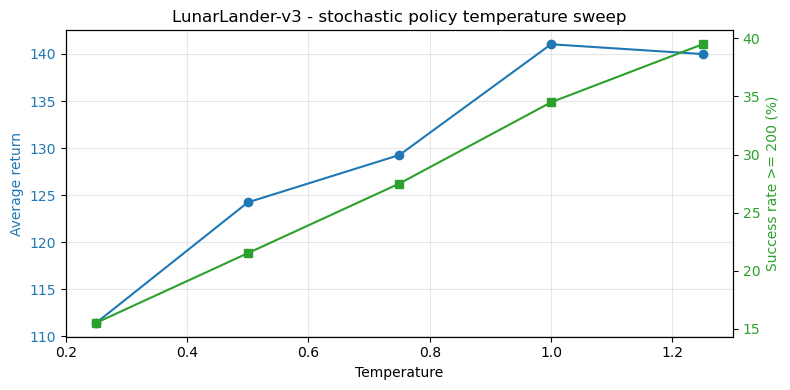

In [11]:
temps = [row["temperature"] for row in temperature_results]
avg_returns = [row["avg_return"] for row in temperature_results]
success_rates = [row["success_rate"] for row in temperature_results]

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(temps, avg_returns, marker="o", color="tab:blue", label="Average return")
ax1.set_xlabel("Temperature")
ax1.set_ylabel("Average return", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(temps, success_rates, marker="s", color="tab:green", label="Success rate")
ax2.set_ylabel("Success rate >= 200 (%)", color="tab:green")
ax2.tick_params(axis="y", labelcolor="tab:green")

plt.title("LunarLander-v3 - stochastic policy temperature sweep")
fig.tight_layout()
plt.show()

## 6. Load and Re-evaluate the Selected LunarLander Checkpoint

The selected checkpoint for final inspection is:

`best_a2c_lunarlander_landing_refine_seed2112_best_train.pt`

The chosen evaluation mode is stochastic with temperature `1.0`, because it produced the best average return in the temperature sweep. Temperature `1.25` is also defensible if the objective is to maximize only the percentage of episodes above `200`, but it had a slightly lower average return.

In [12]:
SELECTED_LUNAR_CHECKPOINT = "best_a2c_lunarlander_landing_refine_seed2112_best_train.pt"
SELECTED_TEMPERATURE = 1.0

candidate_checkpoint_dirs = [
    checkpoint_dir("old", create=False),
    Path("/home/francescofaggioli/DRL_lab"),
    PROJECT_ROOT,
    Path.cwd(),
]

selected_lunar_path = None
for directory in candidate_checkpoint_dirs:
    candidate = directory / SELECTED_LUNAR_CHECKPOINT
    if candidate.exists():
        selected_lunar_path = candidate
        break

if selected_lunar_path is None:
    print("Selected checkpoint not found.")
    print("Run scripts/link_old_checkpoints.py inside Ubuntu, or copy the checkpoint into checkpoints/old.")
else:
    print("Selected checkpoint:", selected_lunar_path)

Selected checkpoint: /mnt/c/Users/checc/OneDrive/Desktop/DLA/DLA_Lab/Reinforcment LLM/LAB_3_LLM/checkpoints/old/best_a2c_lunarlander_landing_refine_seed2112_best_train.pt


In [13]:
if selected_lunar_path is not None:
    env_ll_eval = make_env(
        "LunarLander-v3",
        seed=SEED + 9000,
        continuous=False,
        enable_wind=False,
    )
    obs_scale_ll_raw = torch.ones(8, dtype=torch.float32)
    net_ll_eval = lunar_a2c_from_env(env_ll_eval, hidden_size=64)
    load_a2c_checkpoint(net_ll_eval, selected_lunar_path)

    lunar_metrics = evaluate_a2c_policy(
        env_ll_eval,
        net_ll_eval,
        obs_scale_ll_raw,
        n_eval=200,
        mode="sample",
        temperature=SELECTED_TEMPERATURE,
        seed_start=30_000,
        max_episode_steps=1000,
    )
    env_ll_eval.close()

    print("LUNARLANDER STOCHASTIC EVALUATION")
    print("Average return:      ", round(lunar_metrics["avg_return"], 2))
    print("Std return:          ", round(lunar_metrics["std_return"], 2))
    print("Min return:          ", round(lunar_metrics["min_return"], 2))
    print("Max return:          ", round(lunar_metrics["max_return"], 2))
    print("Average length:      ", round(lunar_metrics["avg_length"], 2))
    print("Success rate >= 200: ", f"{lunar_metrics['success_rate']:.1f}%")
    print("Terminated episodes: ", f"{lunar_metrics['terminated']}/200")
    print("Truncated episodes:  ", f"{lunar_metrics['truncated']}/200")
    print("Action frequencies:  ", [round(x, 3) for x in lunar_metrics["action_freq"]])
else:
    print("Evaluation skipped because the checkpoint is not available in this environment.")

LUNARLANDER STOCHASTIC EVALUATION
Average return:       136.01
Std return:           107.16
Min return:           -99.31
Max return:           258.88
Average length:       638.11
Success rate >= 200:  36.0%
Terminated episodes:  183/200
Truncated episodes:   17/200
Action frequencies:   [0.165, 0.194, 0.473, 0.168]


In [14]:
# Visual check: run only in the local Linux/VS Code setup with display support.
# This cell opens the Gymnasium render window and executes two stochastic episodes.

RUN_LUNAR_RENDER = True

if RUN_LUNAR_RENDER and selected_lunar_path is not None:
    render_env = make_env(
        "LunarLander-v3",
        seed=SEED + 10_000,
        render_mode="human",
        continuous=False,
        enable_wind=False,
    )
    render_net = lunar_a2c_from_env(render_env, hidden_size=64)
    load_a2c_checkpoint(render_net, selected_lunar_path)

    for idx, episode_seed in enumerate([SEED + 10_100, SEED + 10_101], start=1):
        episode = run_a2c_episode(
            render_env,
            render_net,
            torch.ones(8, dtype=torch.float32),
            mode="sample",
            temperature=SELECTED_TEMPERATURE,
            max_episode_steps=1000,
            seed=episode_seed,
        )
        print(f"LunarLander render episode {idx}: return={episode['return']:.2f}, length={episode['length']}")

    render_env.close()
elif selected_lunar_path is None:
    print("LunarLander render skipped because the selected checkpoint is not available.")
else:
    print("LunarLander render skipped. Set RUN_LUNAR_RENDER = True when running locally with display support.")

LunarLander render episode 1: return=222.90, length=584
LunarLander render episode 2: return=187.16, length=522


In [ ]:
# Inline visual check for LunarLander.
# It displays one episode inside Jupyter and prints statistics for two episodes.

SHOW_LUNAR_INLINE_VIDEO = True

if SHOW_LUNAR_INLINE_VIDEO and selected_lunar_path is not None:
    video_env = make_env(
        "LunarLander-v3",
        seed=SEED + 10_000,
        render_mode="rgb_array",
        continuous=False,
        enable_wind=False,
    )
    video_net = lunar_a2c_from_env(video_env, hidden_size=64)
    load_a2c_checkpoint(video_net, selected_lunar_path)

    first_episode_frames = []

    for idx, episode_seed in enumerate([SEED + 10_100, SEED + 10_101], start=1):
        obs, _ = video_env.reset(seed=episode_seed)
        total_reward = 0.0
        actions = []
        frames = []

        with torch.no_grad():
            for _ in range(1000):
                if idx == 1:
                    frames.append(video_env.render())

                obs_t = torch.tensor(obs, dtype=torch.float32) / torch.ones(8, dtype=torch.float32)
                logits, _ = video_net.get_logits_and_value(obs_t)
                dist = torch.distributions.Categorical(logits=logits / SELECTED_TEMPERATURE)
                action = int(dist.sample().item())

                obs, reward, terminated, truncated, _ = video_env.step(action)
                total_reward += float(reward)
                actions.append(action)

                if terminated or truncated:
                    if idx == 1:
                        frames.append(video_env.render())
                    break

        if idx == 1:
            first_episode_frames = frames

        print(f"LunarLander inline episode {idx}: return={total_reward:.2f}, length={len(actions)}")

    video_env.close()

    if first_episode_frames:
        show_frames(first_episode_frames, interval=30, max_display_frames=300)
elif selected_lunar_path is None:
    print("LunarLander video skipped because the selected checkpoint is not available.")
else:
    print("Inline LunarLander video skipped.")

## Final Observations

CartPole validates the A2C implementation: in the old run it reached the maximum greedy return of `500`, and this clean notebook uses the same algorithmic choices with GAE, entropy regularization and gradient clipping.

LunarLander is substantially less stable. The final policy does not solve the environment by the strict criterion of average return at least `200` over evaluation episodes. However, the best runs produce positive average returns and non-trivial success rates. This is a meaningful improvement over the failed early attempts, and the checkpoint/temperature comparisons make the limitation explicit instead of hiding it.

The main practical conclusions are:

- A2C is much more appropriate here than the removed long REINFORCE run;
- CartPole is solved and is a useful implementation sanity check;
- LunarLander benefits from vectorized rollouts, reward scaling, GAE, entropy decay and separate actor/critic networks;
- stochastic evaluation can outperform greedy evaluation because the learned LunarLander policy remains uncertain near landing decisions;
- final claims should report both the average return and the success rate, because each highlights a different behavior of the policy.

## AI and Resource Disclosure

ChatGPT/Codex was used to help restructure the laboratory into clean notebooks and reusable Python utilities. The implementation and conclusions must be verified by rerunning the notebook in the declared Ubuntu/Conda environment. The professor's repository and the official Gymnasium documentation were used as external references for the laboratory setup and environment specifications.